In [ ]:
# Excel dosyasını okuyoruz
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_excel("Xin_E-Commerce.xlsx", sheet_name="E Comm")
df2 = pd.read_excel("Xin_E-Commerce-2.xlsx", sheet_name="E Comm")

In [14]:
# Tüm satır bazında tam tekrar var mı?
print("Tekrarlayan satır sayısı:", df.duplicated().sum())

# CustomerID bazında tekrar var mı (daha kritik)?
print("Tekrarlayan CustomerID sayısı:", df['CustomerID'].duplicated().sum())

Tekrarlayan satır sayısı: 0
Tekrarlayan CustomerID sayısı: 0


Tekrar eden verimiz yok bu nedenle temizlememize de gerek yok

In [47]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,...,DaySinceLastOrder,CashbackAmount,DaySinceLastOrder_eksik,OrderAmountHikeFromlastYear_eksik,Tenure_eksik,OrderCount_eksik,CouponUsed_eksik,HourSpendOnApp_eksik,WarehouseToHome_eksik,Mesafe_Kategorisi_4
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,...,5.0,159.93,0,0,0,0,0,0,0,1. Çeyrek (Çok Yakın)
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,...,0.0,120.90,0,0,1,0,0,0,0,1. Çeyrek (Çok Yakın)
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,...,3.0,120.28,0,0,1,0,0,0,0,4. Çeyrek (Çok Uzak)
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,...,3.0,134.07,0,0,0,0,0,0,0,3. Çeyrek (Uzak)
4,50005,1,0.0,Phone,1,12.0,Credit Card,Male,3.0,3,...,3.0,129.60,0,0,0,0,0,1,0,2. Çeyrek (Yakın)


In [16]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.00,0.0000,1.00
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.00


In [ ]:
# Veri setinin toplam boyutunu (Satır ve Sütun) görelim
print(f"Toplam Satır: {df.shape[0]}")
print(f"Toplam Sütun: {df.shape[1]}")

Toplam Satır: 5630
Toplam Sütun: 20


In [ ]:
# Hangi sütunda kaç tane boş (eksik) satır var?
eksikler = df.isnull().sum()
print("--- Sütunlardaki Eksik Veri Sayıları ---")
print(eksikler[eksikler > 0].sort_values(ascending=False))
# Manuel topladım = 307 + 265 + 264 + 258 + 256 + 255 + 251 = 1.856

--- Sütunlardaki Eksik Veri Sayıları ---
DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
dtype: int64


In [ ]:
# Toplam kaç satırda eksik var ve genel veri setine oranı nedir?
en_az_bir_bos_satir = df.isnull().any(axis=1).sum()
toplam_satir = len(df)
yuzde = (en_az_bir_bos_satir / toplam_satir) * 100

print(f"Toplam Satır Sayısı: {toplam_satir}")
print(f"En Az 1 Eksik Verisi Olan Satır Sayısı: {en_az_bir_bos_satir}")
print(f"Eksik Verili Satırların Genel Oranı: %{yuzde:.2f}")
# Bir detay göze çarpıyor bütün eksik veri satırlarında 1 eksık var ve fazlası yok
# Bu nedenle eksik verileri silme gibi bir şansımız yok

Toplam Satır Sayısı: 5630
En Az 1 Eksik Verisi Olan Satır Sayısı: 1856
Eksik Verili Satırların Genel Oranı: %32.97


In [ ]:
# Her satırda bir eksiğin olması bize bu verilerin rastgele değil de MNAR (Missing not at Random) yani rastgele olmayan sentetik bir şekilde 
# eksiltilmiş bir durumu dile getiriyor. Bu da bana churn oranları ile eksik verilerin bir ilişkisi olup olmadığını düşündürüyor.

#  En az bir bilgisi boş (eksik) olan müşterileri ayıralım
eksik_olanlar = df[df.isnull().any(axis=1)]

# Tüm bilgileri tam olan müşterileri ayıralım
dolu_olanlar = df[~df.isnull().any(axis=1)]

# İki grubun Churn (terk) oranlarını yazdıralım
print("Eksik Verili Müşterilerin Churn Oranı: %", round(eksik_olanlar['Churn'].mean() * 100, 2))
print("Eksiksiz Müşterilerin Churn Oranı:    %", round(dolu_olanlar['Churn'].mean() * 100, 2))


Eksik Verili Müşterilerin Churn Oranı: % 17.08
Eksiksiz Müşterilerin Churn Oranı:    % 16.72


In [ ]:
# Çok büyük bir fark söz konusu değil ama tek tek incelemekte fayda var
# Eksik verisi olan 7 sütunumuzun listesi
eksik_sutunlar = [
    'DaySinceLastOrder', 'OrderAmountHikeFromlastYear', 
    'Tenure', 'OrderCount', 'CouponUsed', 
    'HourSpendOnApp', 'WarehouseToHome'
]

for sutun in eksik_sutunlar:

    # Sadece ilgili sütunu BOŞ olanların Churn oranı
    bos_churn = df[df[sutun].isnull()]['Churn'].mean() * 100
    
    # Sadece ilgili sütunu DOLU olanların Churn oranı
    dolu_churn = df[df[sutun].notnull()]['Churn'].mean() * 100
    
    # Sonuçları ekrana basıyoruz
    print(f"--- {sutun} ---")
    print(f"  Eksik (Boş) İken Churn Oranı: % {bos_churn:.2f}")
    print(f"  Dolu İken Churn Oranı:        % {dolu_churn:.2f}\n")

--- DaySinceLastOrder ---
  Eksik (Boş) İken Churn Oranı: % 17.59
  Dolu İken Churn Oranı:        % 16.80

--- OrderAmountHikeFromlastYear ---
  Eksik (Boş) İken Churn Oranı: % 5.28
  Dolu İken Churn Oranı:        % 17.41

--- Tenure ---
  Eksik (Boş) İken Churn Oranı: % 30.68
  Dolu İken Churn Oranı:        % 16.16

--- OrderCount ---
  Eksik (Boş) İken Churn Oranı: % 6.98
  Dolu İken Churn Oranı:        % 17.31

--- CouponUsed ---
  Eksik (Boş) İken Churn Oranı: % 3.12
  Dolu İken Churn Oranı:        % 17.49

--- HourSpendOnApp ---
  Eksik (Boş) İken Churn Oranı: % 22.75
  Dolu İken Churn Oranı:        % 16.56

--- WarehouseToHome ---
  Eksik (Boş) İken Churn Oranı: % 33.47
  Dolu İken Churn Oranı:        % 16.06



# 3 tane sütunumuzda belirgin farklar çıktı.
# 1.Müşterinin adres/mesafe bilgisi sistemde eksikse veya tanımlanamamışsa, bu müşterilerin 3'te 1'i sistemi terk etmiş.
# Teslimat adresi sorunları terke yol açmış olabilir.
# 2.Müşterilik süresi sisteme işlenmemiş/kaybolmuş kullanıcıların terk oranı neredeyse 2 kat yüksek.
# 3.Uygulamada Geçirilen Süre girilmeyince oran %37 artış gösteriyor


In [ ]:
# Kategorik (objektif) sütunları bulalım Ve düzenleyelim
kategorik_sutunlar = df.select_dtypes(include=['object']).columns

# Her birindeki benzersiz değerlere bakalım
for sutun in kategorik_sutunlar:
    print(f"--- {sutun} Sütunundaki Benzersiz Değerler ---")
    print(df[sutun].unique())
    print("\n")

--- PreferredLoginDevice Sütunundaki Benzersiz Değerler ---
<StringArray>
['Mobile Phone', 'Phone', 'Computer']
Length: 3, dtype: str


--- PreferredPaymentMode Sütunundaki Benzersiz Değerler ---
<StringArray>
['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD',
 'Credit Card']
Length: 7, dtype: str


--- Gender Sütunundaki Benzersiz Değerler ---
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


--- PreferedOrderCat Sütunundaki Benzersiz Değerler ---
<StringArray>
['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion',
 'Grocery']
Length: 6, dtype: str


--- MaritalStatus Sütunundaki Benzersiz Değerler ---
<StringArray>
['Single', 'Divorced', 'Married']
Length: 3, dtype: str




C:\Users\yildi\AppData\Local\Temp\ipykernel_14460\1668943598.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  kategorik_sutunlar = df.select_dtypes(include=['object']).columns


Mobile Phone -> Mobile  ----
CC -> Credit Card  ----
Cod -> Cash on delivery  ----
olarak sadeleştireceğiz

In [24]:
# Ödeme yöntemlerini standart hale getirelim
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace(['CC', 'COD'], ['Credit Card', 'Cash on Delivery'])

# Ürün kategorisindeki 'Mobile' ifadesini 'Mobile Phone' ile birleştirelim
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile Phone', 'Mobile')

# İkisini de alt alta yazdıralım
print("--- Güncel Ödeme Yöntemleri ---")
print(df['PreferredPaymentMode'].unique())

print("\n--- Güncel Ürün Kategorileri ---")
print(df['PreferedOrderCat'].unique())

--- Güncel Ödeme Yöntemleri ---
<StringArray>
['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'E wallet']
Length: 5, dtype: str

--- Güncel Ürün Kategorileri ---
<StringArray>
['Laptop & Accessory', 'Mobile', 'Others', 'Fashion', 'Grocery']
Length: 5, dtype: str


In [ ]:
# Her sütunu kendi medyan değeri ile dolduralım
for sutun in eksik_sutunlar:
    df[f"{sutun}_eksik"] = df[sutun].isnull().astype(int)  # flag ekliyorum!
    df[sutun] = df[sutun].fillna(df[sutun].median())          # sonra dolduruyorum

# Kontrol: Tabloda hiç boş (NaN) sayısal veri kaldı mı?
kalan_eksik = df.isnull().sum().sum()
print(f"Doldurma İşlemi Sonrası Toplam Eksik Veri Sayısı: {kalan_eksik}")

Doldurma İşlemi Sonrası Toplam Eksik Veri Sayısı: 0


In [26]:
# İstatiksel karşılaştırma

print("--- Orijinal Veri (df2) - İstatistikler ---")
display(df2[eksik_sutunlar].describe())

print("\n--- Doldurulmuş Veri (df) - İstatistikler ---")
display(df[eksik_sutunlar].describe())

--- Orijinal Veri (df2) - İstatistikler ---


,DaySinceLastOrder,OrderAmountHikeFromlastYear,Tenure,OrderCount,CouponUsed,HourSpendOnApp,WarehouseToHome
count,5323.000000,5365.000000,5366.000000,5372.000000,5374.000000,5375.000000,5379.000000
mean,4.543491,15.707922,10.189899,3.008004,1.751023,2.931535,15.639896
std,3.654433,3.675485,8.557241,2.939680,1.894621,0.721926,8.531475
min,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000,5.000000
25%,2.000000,13.000000,2.000000,1.000000,1.000000,2.000000,9.000000
50%,3.000000,15.000000,9.000000,2.000000,1.000000,3.000000,14.000000
75%,7.000000,18.000000,16.000000,3.000000,2.000000,3.000000,20.000000
max,46.000000,26.000000,61.000000,16.000000,16.000000,5.000000,127.000000



--- Doldurulmuş Veri (df) - İstatistikler ---


,DaySinceLastOrder,OrderAmountHikeFromlastYear,Tenure,OrderCount,CouponUsed,HourSpendOnApp,WarehouseToHome
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,4.459325,15.674600,10.134103,2.961812,1.716874,2.934636,15.566785
std,3.570626,3.591058,8.357951,2.879248,1.857640,0.705528,8.345961
min,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000,5.000000
25%,2.000000,13.000000,3.000000,1.000000,1.000000,2.000000,9.000000
50%,3.000000,15.000000,9.000000,2.000000,1.000000,3.000000,14.000000
75%,7.000000,18.000000,15.000000,3.000000,2.000000,3.000000,20.000000
max,46.000000,26.000000,61.000000,16.000000,16.000000,5.000000,127.000000


In [27]:
#  Veri setindeki tüm sütun isimlerini görelim
print(df.columns)

#  Sadece son eklenen "_eksik" sütunlarından birini ve içindeki 1'leri kontrol edelim
print(df[['Tenure', 'Tenure_eksik']].head(10))

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount', 'DaySinceLastOrder_eksik',
       'OrderAmountHikeFromlastYear_eksik', 'Tenure_eksik', 'OrderCount_eksik',
       'CouponUsed_eksik', 'HourSpendOnApp_eksik', 'WarehouseToHome_eksik'],
      dtype='str')
   Tenure  Tenure_eksik
0     4.0             0
1     9.0             1
2     9.0             1
3     0.0             0
4     0.0             0
5     0.0             0
6     9.0             1
7     9.0             1
8    13.0             0
9     9.0             1


In [28]:
# Aykırı veri tespit etme
sayisal_sutunlar = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderCount', 
                     'DaySinceLastOrder', 'CouponUsed', 'OrderAmountHikeFromlastYear']

print(f"{'Sütun':<30}{'Alt Sınır':>10}{'Üst Sınır':>10}{'Aykırı Sayısı':>15}{'Aykırı %':>10}")
for sutun in sayisal_sutunlar:
    Q1 = df[sutun].quantile(0.25)
    Q3 = df[sutun].quantile(0.75)
    IQR = Q3 - Q1
    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR
    
    aykiri = df[(df[sutun] < alt_sinir) | (df[sutun] > ust_sinir)]
    aykiri_sayisi = len(aykiri)
    aykiri_yuzde = aykiri_sayisi / len(df) * 100
    
    print(f"{sutun:<30}{alt_sinir:>10.1f}{ust_sinir:>10.1f}{aykiri_sayisi:>15}{aykiri_yuzde:>9.2f}%")

Sütun                          Alt Sınır Üst Sınır  Aykırı Sayısı  Aykırı %
Tenure                             -15.0      33.0              4     0.07%
WarehouseToHome                     -7.5      36.5              2     0.04%
HourSpendOnApp                       0.5       4.5              6     0.11%
OrderCount                          -2.0       6.0            703    12.49%
DaySinceLastOrder                   -5.5      14.5             62     1.10%
CouponUsed                          -0.5       3.5            629    11.17%
OrderAmountHikeFromlastYear          5.5      25.5             33     0.59%


In [29]:
# Yüksek sipariş verenlerin (OrderCount > 5 olanlar) Churn oranı nedir?
yuksek_siparis = df[df['OrderCount'] > 5]
print("\n--- Yüksek sipariş verenlerin Churn Oranı:")
print(yuksek_siparis['Churn'].value_counts(normalize=True) * 100)

dusuk_siparis = df[df['OrderCount'] <= 2]

print("\n--- Düşük sipariş verenlerin Churn Oranı:")
print(dusuk_siparis['Churn'].value_counts(normalize=True) * 100)

print("\n--- Genel Churn Oranı ---")
print(df['Churn'].value_counts(normalize=True) * 100)


--- Yüksek sipariş verenlerin Churn Oranı:
Churn
0    84.047619
1    15.952381
Name: proportion, dtype: float64

--- Düşük sipariş verenlerin Churn Oranı:
Churn
0    82.548339
1    17.451661
Name: proportion, dtype: float64

--- Genel Churn Oranı ---
Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


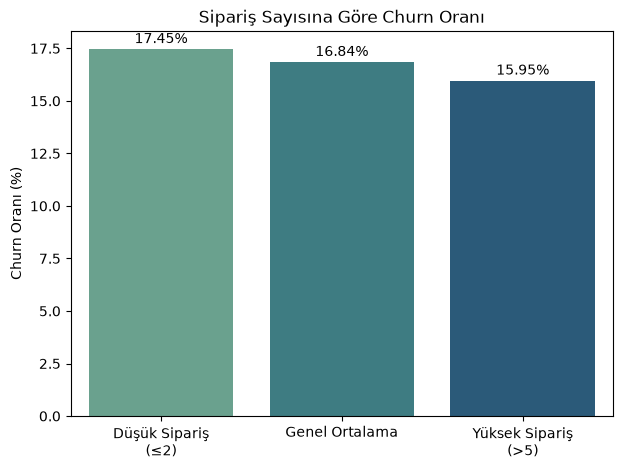

In [30]:
gruplar = ['Düşük Sipariş\n(≤2)', 'Genel Ortalama', 'Yüksek Sipariş\n(>5)']
churn_oranlari = [
    dusuk_siparis['Churn'].mean() * 100,
    df['Churn'].mean() * 100,
    yuksek_siparis['Churn'].mean() * 100
]

plt.figure(figsize=(7,5))
sns.barplot(x=gruplar, y=churn_oranlari, hue=gruplar, palette='crest', legend=False)
plt.title('Sipariş Sayısına Göre Churn Oranı')
plt.ylabel('Churn Oranı (%)')
for i, v in enumerate(churn_oranlari):
    plt.text(i, v + 0.3, f'{v:.2f}%', ha='center')
plt.show()

In [31]:
# Verilerimiz doğal durumunda çıktı yüksek sipraiş verenlerin ve genel churn oranları oldukça yakın

# Memnuniyet puanına göre ortalama churn oranını ve müşteri sayısını bulalım

memnuniyet_analizi = df.groupby('SatisfactionScore')['Churn'].agg(['count', 'mean'])
memnuniyet_analizi['mean'] = memnuniyet_analizi['mean'] * 100 # Yüzdeye çevirelim
memnuniyet_analizi.columns = ['Müşteri Sayısı', 'Churn Oranı (%)']

print("--- Memnuniyet Puanına Göre Churn Analizi ---")
print(memnuniyet_analizi)

--- Memnuniyet Puanına Göre Churn Analizi ---
                   Müşteri Sayısı  Churn Oranı (%)
SatisfactionScore                                 
1                            1164        11.512027
2                             586        12.627986
3                            1698        17.196702
4                            1074        17.132216
5                            1108        23.826715


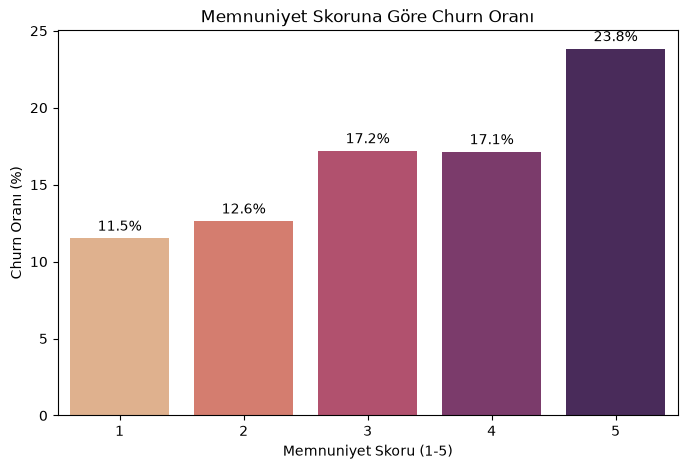

In [32]:
memnuniyet_churn = df.groupby('SatisfactionScore')['Churn'].mean() * 100

plt.figure(figsize=(8,5))
sns.barplot(x=memnuniyet_churn.index, y=memnuniyet_churn.values,
            hue=memnuniyet_churn.index, palette='flare', legend=False)
plt.title('Memnuniyet Skoruna Göre Churn Oranı')
plt.xlabel('Memnuniyet Skoru (1-5)')
plt.ylabel('Churn Oranı (%)')
for i, v in enumerate(memnuniyet_churn.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.show()

In [33]:
# Puan=5 verip churn eden müşterilerin diğer özellikleri normalden farklı mı?
puan5_churn = df[(df['SatisfactionScore']==5) & (df['Churn']==1)]
puan5_kalan = df[(df['SatisfactionScore']==5) & (df['Churn']==0)]

print("Puan=5 & Churn=1 grubunun Complain oranı:", puan5_churn['Complain'].mean())
print("Puan=5 & Churn=0 grubunun Complain oranı:", puan5_kalan['Complain'].mean())

print("\nPuan=5 & Churn=1 grubunun Tenure ortalaması:", puan5_churn['Tenure'].mean())
print("Puan=5 & Churn=0 grubunun Tenure ortalaması:", puan5_kalan['Tenure'].mean())


Puan=5 & Churn=1 grubunun Complain oranı: 0.45454545454545453
Puan=5 & Churn=0 grubunun Complain oranı: 0.23933649289099526

Puan=5 & Churn=1 grubunun Tenure ortalaması: 3.015151515151515
Puan=5 & Churn=0 grubunun Tenure ortalaması: 11.680094786729859


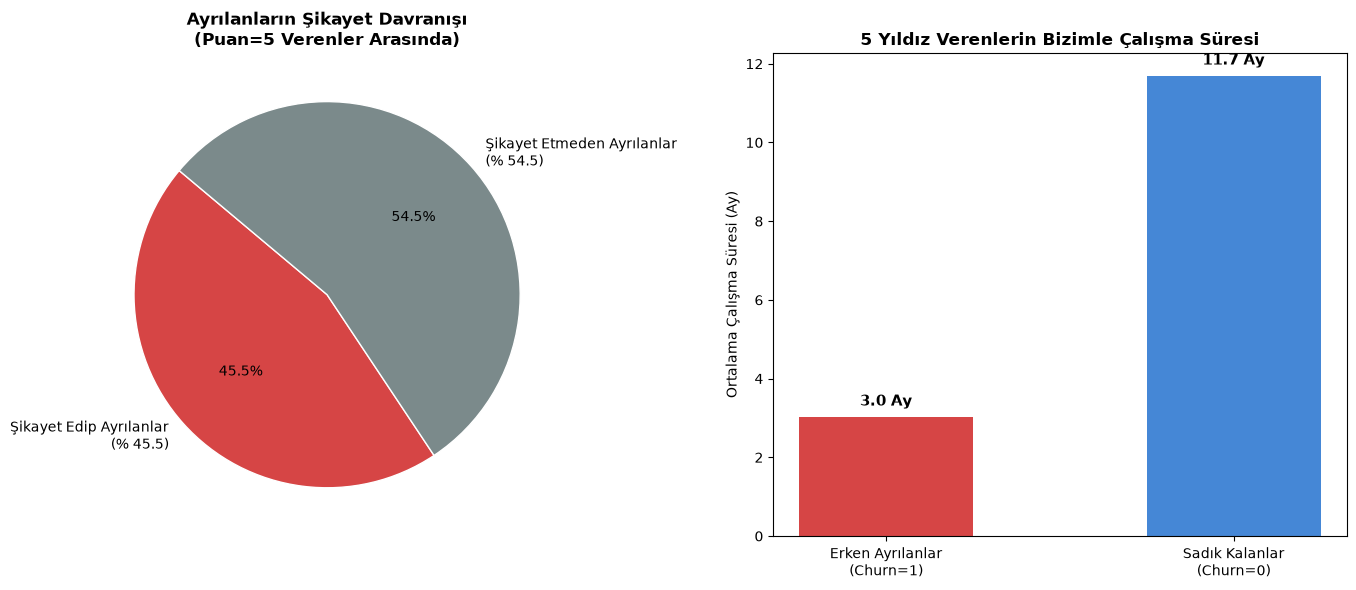

In [ ]:
# Figür ve 2 alt grafik oluştur
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Puan=5 verip ayrılanlar (puan5_churn) içinde şikayet edenlerin oranını buluyoruz
sikayet_edenlerin_orani = puan5_churn['Complain'].mean() * 100
sessizce_ayrilanlarin_orani = 100 - sikayet_edenlerin_orani

oranlar = [sikayet_edenlerin_orani, sessizce_ayrilanlarin_orani]
etiketler = ['Şikayet Edip Ayrılanlar\n(% {:.1f})'.format(sikayet_edenlerin_orani), 
             'Şikayet Etmeden Ayrılanlar\n(% {:.1f})'.format(sessizce_ayrilanlarin_orani)]

# Ayrılanların iç dağılımı olduğu için Pasta Grafiği (Pie Chart) hikayeyi çok iyi anlatır
ax1.pie(oranlar, labels=etiketler, colors=['#d64545', '#7b8a8b'], autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'white'})
ax1.set_title('Ayrılanların Şikayet Davranışı\n(Puan=5 Verenler Arasında)', fontsize=12, fontweight='bold')

# Churn=1 ve Churn=0 gruplarının ortalama Tenure değerleri
tenure_degerleri = [puan5_churn['Tenure'].mean(), puan5_kalan['Tenure'].mean()]
tenure_etiketleri = ['Erken Ayrılanlar\n(Churn=1)', 'Sadık Kalanlar\n(Churn=0)']

# Karşılaştırma çubuk grafiği
ax2.bar(tenure_etiketleri, tenure_degerleri, color=['#d64545', '#4587d6'], width=0.5)
ax2.set_title('5 Yıldız Verenlerin Bizimle Çalışma Süresi', fontsize=12, fontweight='bold')
ax2.set_ylabel('Ortalama Çalışma Süresi (Ay)')

# Hikayeyi netleştirmek için çubukların üzerine doğrudan ay değerlerini yazdırıyoruz
for i, v in enumerate(tenure_degerleri):
    ax2.text(i, v + 0.3, f"{v:.1f} Ay", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [35]:
# CityTier kırılımında ortalama Churn oranı ve müşteri sayısı
city_analizi = df.groupby('CityTier').agg(
    Musteri_Sayisi=('Churn', 'count'),
    Churn_Edenler=('Churn', 'sum'),
    Churn_Orani=('Churn', lambda x: (x.mean() * 100).round(2))
)

print(city_analizi)

          Musteri_Sayisi  Churn_Edenler  Churn_Orani
CityTier                                            
1                   3666            532        14.51
2                    242             48        19.83
3                   1722            368        21.37


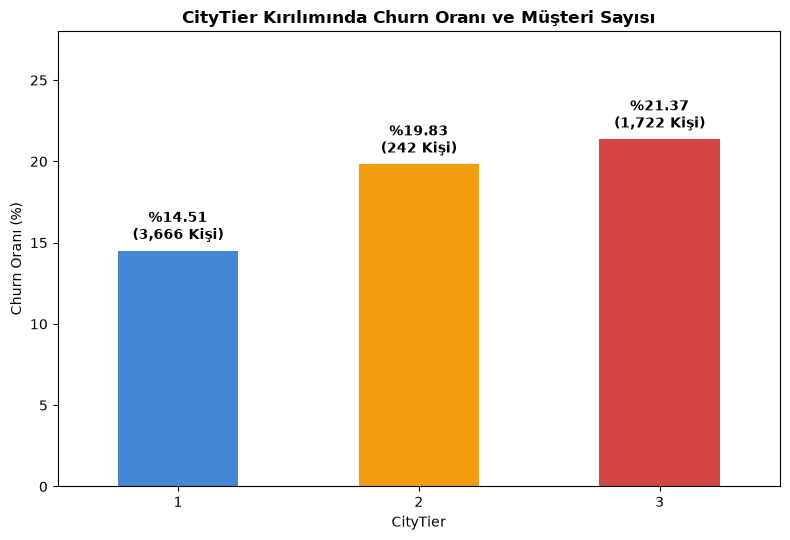

In [36]:
# Sadece Churn Oranı'nı çizdiriyoruz
ax = city_analizi['Churn_Orani'].plot(
    kind='bar', 
    figsize=(8, 5.5), 
    color=['#4587d6', '#f39c12', '#d64545'],
    rot=0
)

# Her çubuğun üstüne hem % Churn Oranını hem de Müşteri Sayısını yazdırıyoruz
for i, p in enumerate(ax.patches):
    churn_orani = p.get_height()
    musteri_sayisi = city_analizi['Musteri_Sayisi'].iloc[i]
    
    # Etiket metni: Örn: %14.51 \n (3,666 Kişi)
    etiket = f"%{churn_orani}\n({musteri_sayisi:,} Kişi)"
    
    ax.annotate(etiket, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontweight='bold',
                fontsize=10)

# Görsel düzenlemeler
plt.title('CityTier Kırılımında Churn Oranı ve Müşteri Sayısı', fontsize=12, fontweight='bold')
plt.ylabel('Churn Oranı (%)')
plt.xlabel('CityTier')
plt.ylim(0, 28)  # Yazılar sığsın diye üst sınırı biraz genişlettik
plt.tight_layout()

plt.show()

In [37]:
# CityTier'a göre WarehouseToHome ortalaması
print("--- CityTier'a göre WarehouseToHome Ortalaması ---")
print(df.groupby('CityTier')['WarehouseToHome'].agg(['mean', 'median', 'count']))

# İkisi arasındaki korelasyon (doğrusal ilişki gücü, -1 ile +1 arası)
korelasyon = df['CityTier'].corr(df['WarehouseToHome'])
print(f"\nCityTier ile WarehouseToHome korelasyonu: {korelasyon:.3f}")

--- CityTier'a göre WarehouseToHome Ortalaması ---
               mean  median  count
CityTier                          
1         15.507638    14.0   3666
2         14.946281    13.0    242
3         15.779907    14.0   1722

CityTier ile WarehouseToHome korelasyonu: 0.014


CityTier 3'teki yüksek kayıp oranının sebebi kesinlikle lojistik mesafe (WarehouseToHome) değil. Çünkü tüm şehir gruplarında ortalama depo-ev mesafesi ~15 birim ile eşit seviyede.
o zaman yakın orta ve uzak olmak üzere üçlü bir karşılaştırma yaparak depo mesafesinin churn oranınana katkısına bakalım

In [38]:
#  Mesafe verisini %25'lik 4 eşit dilime bölüyoruz
df['Mesafe_Kategorisi_4'] = pd.qcut(
    df['WarehouseToHome'], 
    q=4, 
    labels=['1. Çeyrek (Çok Yakın)', '2. Çeyrek (Yakın)', '3. Çeyrek (Uzak)', '4. Çeyrek (Çok Uzak)']
)

# 4 gruba göre Churn ve mesafe aralığı analizi
mesafe_analizi_4 = df.groupby('Mesafe_Kategorisi_4', observed=False).agg(
    Min_Mesafe=('WarehouseToHome', 'min'),
    Max_Mesafe=('WarehouseToHome', 'max'),
    Musteri_Sayisi=('Churn', 'count'),
    Churn_Edenler=('Churn', 'sum'),
    Churn_Orani=('Churn', lambda x: round(x.mean() * 100, 2))
)

print(mesafe_analizi_4)

                       Min_Mesafe  Max_Mesafe  Musteri_Sayisi  Churn_Edenler  \
Mesafe_Kategorisi_4                                                            
1. Çeyrek (Çok Yakın)         5.0         9.0            1695            222   
2. Çeyrek (Yakın)            10.0        14.0            1527            260   
3. Çeyrek (Uzak)             15.0        20.0            1065            192   
4. Çeyrek (Çok Uzak)         21.0       127.0            1343            274   

                       Churn_Orani  
Mesafe_Kategorisi_4                 
1. Çeyrek (Çok Yakın)        13.10  
2. Çeyrek (Yakın)            17.03  
3. Çeyrek (Uzak)             18.03  
4. Çeyrek (Çok Uzak)         20.40  


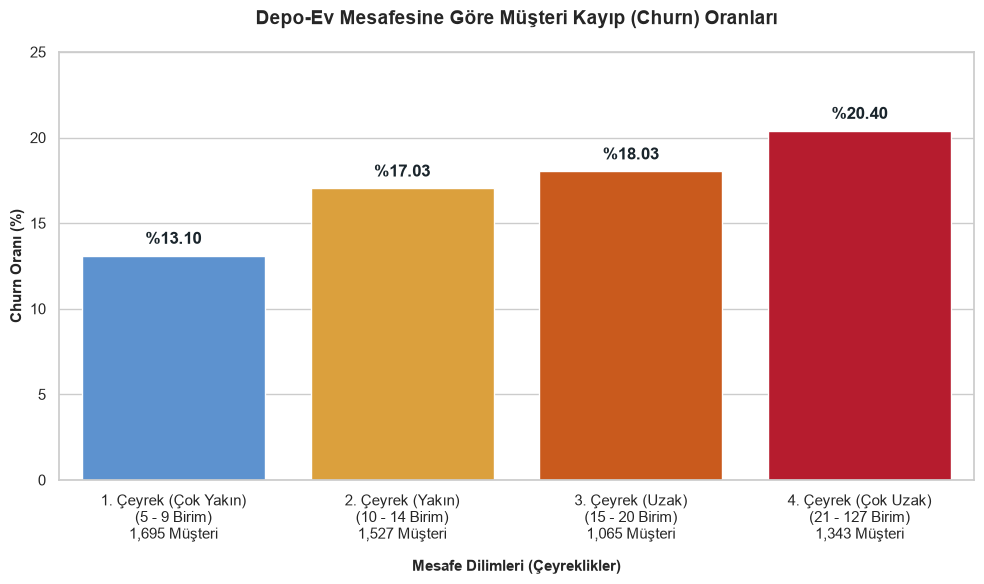

In [39]:
# X ekseni etiketleri
kategoriler = [
    '1. Çeyrek (Çok Yakın)\n(5 - 9 Birim)\n1,695 Müşteri',
    '2. Çeyrek (Yakın)\n(10 - 14 Birim)\n1,527 Müşteri',
    '3. Çeyrek (Uzak)\n(15 - 20 Birim)\n1,065 Müşteri',
    '4. Çeyrek (Çok Uzak)\n(21 - 127 Birim)\n1,343 Müşteri'
]

churn_oranlari = [13.10, 17.03, 18.03, 20.40]

# Grafik Boyutu ve Tema
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Risk artışını gösteren özel renk paleti
renkler = ['#4A90E2', '#F5A623', '#E65100', '#D0021B']

# Çubuk Grafik (Yeni Seaborn sözdizimi ile uyarısız versiyon)
ax = sns.barplot(
    x=kategoriler, 
    y=churn_oranlari, 
    hue=kategoriler, 
    palette=renkler, 
    legend=False
)

# Her çubuğun tepesine Churn Yüzdesini ekleme
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'%{height:.2f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 6),
                textcoords='offset points',
                fontweight='bold',
                fontsize=12,
                color='#1A252C')

# Başlık ve Eksenler
plt.title('Depo-Ev Mesafesine Göre Müşteri Kayıp (Churn) Oranları', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Churn Oranı (%)', fontsize=11, fontweight='bold')
plt.xlabel('Mesafe Dilimleri (Çeyreklikler)', fontsize=11, fontweight='bold', labelpad=12)
plt.ylim(0, 25)

plt.tight_layout()
plt.show()

1. İlk Kritik Kırılma Noktası: 9 Birim Mesafe 1. Çeyrek (%13.10) ile 2. Çeyrek (%17.03) arasında yaklaşık %4'lük anı bir sıçrama var.Müşteri depodan 9 birimden daha uzaktaysa, sadakat gözle görülür şekilde düşmeye başlıyor. İlk tehlike çanı 10. birimde çalıyor.
2. Kademeli Risk Artışı (%13.10 -> %20.40)Mesafe arttıkça risk istikrarlı şekilde tırmanıyor: %13.10 -> %17.03 -> %18.03 -> %20.40.En yakın grup ile en uzak grup arasında kayıp riski %55 oranında artmış durumda.
3. En Uzak Müşterilerin Durumu (4. Çeyrek)21 ile 127 birim arasındaki müşterilerde kayıp oranı %20.40 ile zirve yapıyor. Lojistik operasyonların zorlaştığı bu bölge, kaybedilen her 5 müşteriden 1'ini temsil ediyor.

--- Cinsiyet ve Medeni Duruma Göre Churn Oranları ---
Cinsiyet Medeni Durum  Toplam Müşteri  Terk Eden  Churn Oranı (%)
  Female     Divorced             348         48            13.79
  Female      Married            1140        112             9.82
  Female       Single             758        188            24.80
    Male     Divorced             500         76            15.20
    Male      Married            1846        232            12.57
    Male       Single            1038        292            28.13


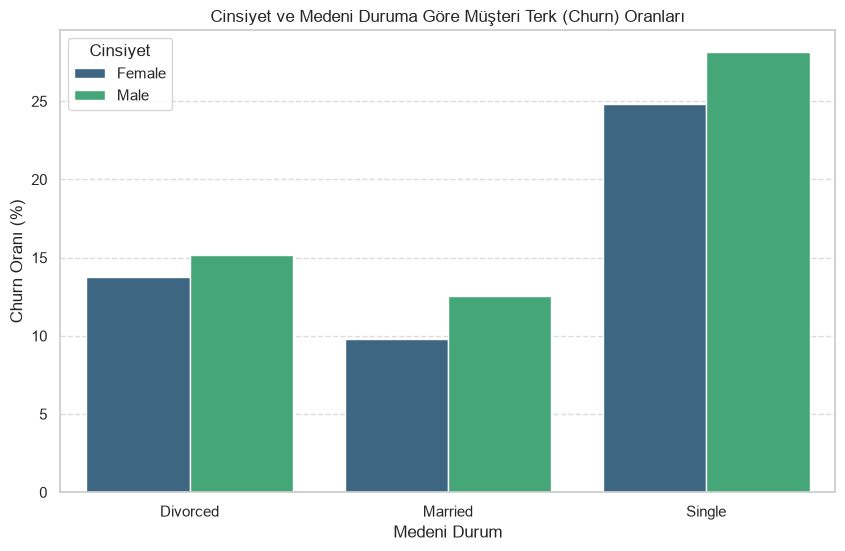

In [40]:
# Cinsiyet ve Medeni Duruma göre Churn oranlarını gruplama
churn_demographics = df.groupby(['Gender', 'MaritalStatus']).agg(
    Toplam_Musteri=('Churn', 'count'),
    Terk_Eden_Musteri=('Churn', 'sum'),
    Churn_Orani=('Churn', 'mean') # Ortalama churn, 1'lerin oranı (yüzdesi) demektir
).reset_index()

# Churn oranını yüzde formatına çevirme (Örn: %15.4)
churn_demographics['Churn_Orani'] = (churn_demographics['Churn_Orani'] * 100).round(2)

# Sütun isimlerini daha okunabilir hale getirme
churn_demographics.rename(columns={
    'Gender': 'Cinsiyet',
    'MaritalStatus': 'Medeni Durum',
    'Toplam_Musteri': 'Toplam Müşteri',
    'Terk_Eden_Musteri': 'Terk Eden',
    'Churn_Orani': 'Churn Oranı (%)'
}, inplace=True)

# Sonucu ekrana yazdırma
print("--- Cinsiyet ve Medeni Duruma Göre Churn Oranları ---")
print(churn_demographics.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=churn_demographics, 
    x='Medeni Durum', 
    y='Churn Oranı (%)', 
    hue='Cinsiyet', 
    palette='viridis'
)
plt.title('Cinsiyet ve Medeni Duruma Göre Müşteri Terk (Churn) Oranları')
plt.ylabel('Churn Oranı (%)')
plt.xlabel('Medeni Durum')
plt.legend(title='Cinsiyet')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Bekarlarla aramız iyi değil

In [41]:
#  Medeni duruma göre uygulamada geçirilen ortalama süreyi hesaplama
app_time_summary = df.groupby('MaritalStatus')['HourSpendOnApp'].agg(['mean', 'median', 'count']).reset_index()
app_time_summary.columns = ['Medeni Durum', 'Ortalama Süre (Saat)', 'Medyan Süre', 'Müşteri Sayısı']
print("--- Medeni Duruma Göre Uygulama Kullanım Süreleri ---")
print(app_time_summary)

--- Medeni Duruma Göre Uygulama Kullanım Süreleri ---
  Medeni Durum  Ortalama Süre (Saat)  Medyan Süre  Müşteri Sayısı
0     Divorced              2.956368          3.0             848
1      Married              2.957468          3.0            2986
2       Single              2.886414          3.0            1796


In [42]:
#  Medeni duruma göre kupon kullanımı ve son sipariş süresi ortalamalarını hesaplama
behavior_summary = df.groupby('MaritalStatus')[['CouponUsed', 'DaySinceLastOrder']].agg(['mean', 'median']).reset_index()
print("--- Medeni Duruma Göre Kupon Kullanımı ve Son Sipariş Süresi ---")
print(behavior_summary)

--- Medeni Duruma Göre Kupon Kullanımı ve Son Sipariş Süresi ---
  MaritalStatus CouponUsed        DaySinceLastOrder       
                      mean median              mean median
0      Divorced   1.857311    1.0          4.544811    3.0
1       Married   1.734092    1.0          4.609511    3.0
2        Single   1.621938    1.0          4.169265    3.0


Ortalamalar: Bekarlar ortalama 4.17 gün önce sipariş vermişken; bu süre boşanmışlarda 4.54 gün, evlilerde ise 4.61 gün civarında.

Kritik Çelişki ve Büyük İçgörü: Bekar müşteriler aslında diğer gruplara göre daha yakın bir zamanda sipariş vermişler (gün sayısı daha düşük). Ancak buna rağmen en yüksek Churn oranı bekarlarda (%25-28) görülüyor.

Bu Ne Anlama Geliyor?: Bekar kullanıcılar uygulamayı yeni denemiş veya yakın zamanda bir kez alışveriş yapmışlar ancak deneyimden memnun kalmadıkları için hızlıca küsüp platformu terk etmişler. Evli veya boşanmış kullanıcılar ise daha uzun süredir platformda kalıp sadıklaşırken, bekarlar ilk deneyimlerinde hayal kırıklığı yaşayıp kalıcı olmuyorlar. 5 Yıldız verip memnun olup 3 ay ortalama ile ayrılan grup olma ihtimaline karşı medeni durum memnuniyet ve kullanım süresini karşılaştıralım.

In [ ]:
# 5 üzerinden 5 yıldız veren, ilk 3 ayda (Tenure <= 3) olan ve churn eden toplam müşteri sayısı
total_high_sat_early_churn = df[(df['SatisfactionScore'] == 5) & (df['Tenure'] <= 3) & (df['Churn'] == 1)]

print(f"Toplam 5 Yıldız Verip İlk 3 Ayda Terk Eden Müşteri Sayısı: {len(total_high_sat_early_churn)}")

# Bu grubun medeni durum kırılımı ve yüzdeleri
marital_breakdown_count = total_high_sat_early_churn['MaritalStatus'].value_counts()
marital_breakdown_pct = total_high_sat_early_churn['MaritalStatus'].value_counts(normalize=True) * 100

print("\n--- Bu Grubun Medeni Durum Dağılımı (Sayı) ---")
print(marital_breakdown_count)

print("\n--- Bu Grubun Medeni Durum Dağılımı (%) ---")
print(marital_breakdown_pct.round(2))

# Genel olarak 5 yıldız verip ilk 3 ayda olan bekar müşterilerin kendi içindeki churn (terk) oranı
single_high_sat_early = df[(df['SatisfactionScore'] == 5) & (df['Tenure'] <= 3) & (df['MaritalStatus'] == 'Single')]
single_churn_rate = (single_high_sat_early['Churn'].mean() * 100).round(2)

print(f"\nBekar olup 5 yıldız veren ve ilk 3 ayda olan müşterilerin Churn Oranı: %{single_churn_rate}")

Toplam 5 Yıldız Verip İlk 3 Ayda Terk Eden Müşteri Sayısı: 200

--- Bu Grubun Medeni Durum Dağılımı (Sayı) ---
MaritalStatus
Single      116
Married      66
Divorced     18
Name: count, dtype: int64

--- Bu Grubun Medeni Durum Dağılımı (%) ---
MaritalStatus
Single      58.0
Married     33.0
Divorced     9.0
Name: proportion, dtype: float64

Bekar olup 5 yıldız veren ve ilk 3 ayda olan müşterilerin Churn Oranı: %65.17


In [ ]:
# Tüm müşterilerin genel sipariş ortalaması
ortalama_siparis = df['OrderCount'].mean()
print(f"Tüm Müşterilerin Ortalama Sipariş Sayısı: {ortalama_siparis:.2f}")

# Churn (Terk Edenler) vs Kalan Müşterilere Göre Sipariş Ortalaması
print("\n--- Terk Eden (Churn=1) vs Kalan (Churn=0) Müşterilerin Sipariş Ortalamaları ---")
siparis_krilimi = df.groupby('Churn')['OrderCount'].mean().reset_index()
siparis_krilimi.columns = ['Churn (Terk Etme Durumu)', 'Ortalama Sipariş Adedi']
print(siparis_krilimi.to_string(index=False))

# Medeni Duruma Göre Sipariş Ortalaması
print("\n--- Medeni Duruma Göre Sipariş Ortalamaları ---")
medeni_durum_siparis = df.groupby('MaritalStatus')['OrderCount'].mean().reset_index()
medeni_durum_siparis.columns = ['Medeni Durum', 'Ortalama Sipariş Adedi']
print(medeni_durum_siparis.to_string(index=False))

Tüm Müşterilerin Ortalama Sipariş Sayısı: 2.96

--- Terk Eden (Churn=1) vs Kalan (Churn=0) Müşterilerin Sipariş Ortalamaları ---
 Churn (Terk Etme Durumu)  Ortalama Sipariş Adedi
                        0                2.992952
                        1                2.808017

--- Medeni Duruma Göre Sipariş Ortalamaları ---
Medeni Durum  Ortalama Sipariş Adedi
    Divorced                3.103774
     Married                3.056597
      Single                2.737194


In [57]:
# Detaylı özet tablo
detayli_tablo = df.groupby('PreferedOrderCat')['Churn'].agg(
    Toplam_Musteri='count',
    Terk_Eden_Musteri='sum',
    Churn_Orani_Yuzde=lambda x: (x.mean() * 100)
).reset_index()

# Oranları virgülden sonra 2 basamağa yuvarlayalım
detayli_tablo['Churn_Orani_Yuzde'] = detayli_tablo['Churn_Orani_Yuzde'].round(2)

print(detayli_tablo)

     PreferedOrderCat  Toplam_Musteri  Terk_Eden_Musteri  Churn_Orani_Yuzde
0             Fashion             826                128              15.50
1             Grocery             410                 20               4.88
2  Laptop & Accessory            2050                210              10.24
3              Mobile            2080                570              27.40
4              Others             264                 20               7.58


In [45]:
df.to_excel('final.xlsx',index=False)